# Paso 1: Importar las librerías necesarias

Librerías esenciales para la manipulación de datos y cálculos matemáticos. `pandas` para manejar el archivo Excel, y `numpy` para los cálculos numéricos.


In [1]:
import pandas as pd
import numpy as np

# Paso 2: Leer el archivo `.xlsx`

Leer el archivo Excel usando la función `read_excel` de pandas. 


In [3]:
archivo_excel = 'pmi_ejercicio.xlsx'
df = pd.read_excel(archivo_excel)

# Paso 3: Mostrar los primeros registros del DataFrame

En este paso, se verán las primeras filas del DataFrame para entender su estructura y contenido. Esto nos permitirá identificar las columnas clave para los siguientes cálculos.


In [4]:
# Mostrar las primeras 5 filas del DataFrame
df.head()


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,Computer,data,result,pie,sugar
1,Cherry,2,8,9,44260,25
2,Strawberry,0,0,1,5,19
3,Digital,1670,1683,85,5,4
4,Information,3325,3982,378,512,13


In [7]:
df.columns = ['Unnamed_0', 'Computer', 'data', 'result', 'pie', 'sugar']

# Paso 4: Calcular P_alpha para una de las columnas numéricas

Ahora, con una de las columnas: `result` calcularé P_alpha. 


In [8]:
alpha = 0.75


frecuencias = df['result'].value_counts()

# Calcular P_alpha
P_alpha = (frecuencias ** alpha) / np.sum(frecuencias ** alpha)
P_alpha


result    0.2
9         0.2
1         0.2
85        0.2
378       0.2
Name: result, dtype: float64

# Paso 4: Calcular PPMI

Con`result` y `sugar` podemos calcular el PPMI.


In [10]:

P_x = df['result'].value_counts(normalize=True)
P_y = df['sugar'].value_counts(normalize=True)

P_xy = pd.crosstab(df['result'], df['sugar'], normalize='all')


PPMI = np.maximum(0, np.log2(P_xy / (P_x[:, None] * P_y[None, :])))
PPMI


/var/folders/vf/44lz8h455mvflsvv9khsdx5w0000gn/T/ipykernel_33448/3528019004.py:7: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  PPMI = np.maximum(0, np.log2(P_xy / (P_x[:, None] * P_y[None, :])))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


sugar,4,13,19,25,sugar
result,,,,,
1,0.000000,0.000000,2.321928,0.000000,0.000000
9,0.000000,0.000000,0.000000,2.321928,0.000000
85,2.321928,0.000000,0.000000,0.000000,0.000000
378,0.000000,2.321928,0.000000,0.000000,0.000000
result,0.000000,0.000000,0.000000,0.000000,2.321928


# Paso 6: Gráficos

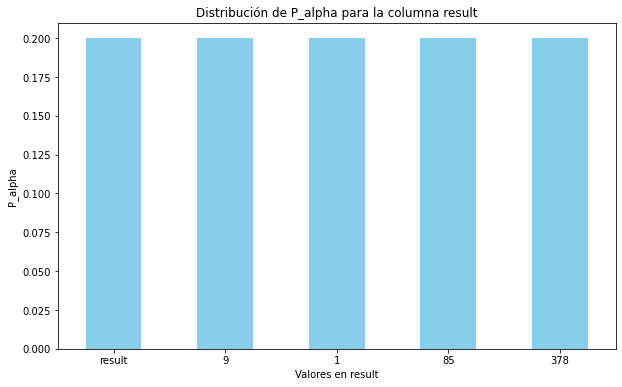

In [11]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
P_alpha.plot(kind='bar', color='skyblue')
plt.title('Distribución de P_alpha para la columna result')
plt.xlabel('Valores en result')
plt.ylabel('P_alpha')
plt.xticks(rotation=0)
plt.show()


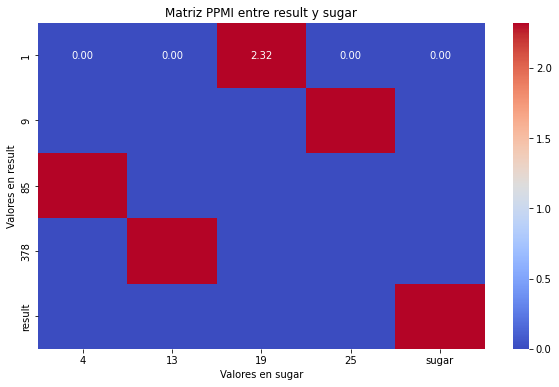

In [12]:
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.heatmap(PPMI, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matriz PPMI entre result y sugar')
plt.xlabel('Valores en sugar')
plt.ylabel('Valores en result')
plt.show()
